# collect enceladus seed set

In [1]:
# make a csv table with compound name, kegg ID, kegg name, comment, source

In [2]:
import csv
import ast
import pandas as pd
import matplotlib.pyplot as plt
from decimal import Decimal
from scipy.stats import spearmanr
import copy
from bokeh.plotting import figure, output_file, show
from bokeh.models import HoverTool

def csv2dict(csv_file_path):
    result_dict = {}
    with open(csv_file_path, 'r') as csv_file:
        csv_reader = csv.reader(csv_file)
        
        for row in csv_reader:
            try:
                result_dict[row[0]] = ast.literal_eval(row[1])  # value is list
            except:
                result_dict[row[0]] = row[1]
    return result_dict

def dict2csv(my_dict, csv_file_path):
    with open(csv_file_path, 'w', newline='') as csv_file:
        csv_writer = csv.writer(csv_file)
        for key, value in my_dict.items():
            csv_writer.writerow([key] + [value])

def todata(dict1, dict2, val_type = 'MEAN'):
    valid_keys = list(dict1.keys() & dict2.keys())
    data1 = [dict1[x] for x in valid_keys]
    data2 = [dict2[x] for x in valid_keys]
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
        
    if type(data2[0]) == dict:
        data2 = [x[val_type] for x in data2]
    
    return valid_keys, data1, data2

def spearman(dict1, dict2):
    valid_keys, data1, data2 = todata(dict1, dict2)
    correlation, p_value = spearmanr(data1, data2)
    p_value = '%.2E' % Decimal(p_value)
    return correlation, p_value

def scatter(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    fig, ax = plt.subplots()
    
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(data1, data2, marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    # plt.savefig('scatter.png')
    ax.axline((0, 0), slope=1, color='k')
    plt.show()

def histogram(dict1, val_type = 'MEAN', bins = 10, x_axis = 'x-axis', y_axis ='counts'):
    data1 = list(dict1.values())
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
    
    plt.hist(data1, bins=bins, edgecolor='k')
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

In [3]:
cpd2name = csv2dict('../data/assets/cpd2nameShort.csv')
cpd2nameLong = csv2dict('../data/assets/cpd2name.csv')


module2name = csv2dict('../data/assets/module2name.csv')
module2rns = csv2dict('../data/assets/module2rns.csv')

rn2cpds = csv2dict('../data/assets/rn2cpds_SI.csv')
rn2modules = csv2dict('../data/assets/rn2modules.csv')
rn2def = csv2dict('../data/assets/rn2def_versions.csv')
rn2rules = pd.read_pickle('../data/assets/rn2rules.20230224.pkl')
rn2eqn_SI = csv2dict('../data/assets/rn2eqn_SI.csv')

In [4]:
# check if cpd is used in any reactions

for r, cpds in rn2cpds.items():
    for c in cpds:
        if c == 'C15521':
            print(r, cpds)

R07210 ['C00001', 'C01847', 'C00061', 'C00007', 'C00071', 'C15521', 'C00094']


In [5]:
# read enceladus_seed_cpds
df = pd.read_csv('../../enceladus_seed_cpds.csv')
df

,formula,compound_names,KEGG_ID,comment,source
0,H2O,H2O; Water,C00001,confirmed,Peter et al. 2023 nature astronomy; Detection...
1,CO2,CO2; Carbon dioxide,C00011,confirmed,Peter et al. 2023 nature astronomy; Detection...
2,CO,CO; Carbon monoxide,C00237,confirmed,Peter et al. 2023 nature astronomy; Detection...
3,CH4,Methane; CH4,C01438,confirmed,Peter et al. 2023 nature astronomy; Detection...
4,NH3,Ammonia; NH3,C00014,confirmed,Peter et al. 2023 nature astronomy; Detection...
...,...,...,...,...,...
171,0,Picolinic acid,C10164,0,Oba et al. 2023. nature communications; Uracil...
172,0,isonicotinic acid,C07446,0,Oba et al. 2023. nature communications; Uracil...
173,0,nicotinamide,C00153,0,Oba et al. 2023. nature communications; Uracil...
174,0,isonicotinamide,C02421,0,Oba et al. 2023. nature communications; Uracil...


In [6]:
enceladus_seed = set(df['KEGG_ID'])
enceladus_seed.remove('0')
print(len(enceladus_seed))

106


In [7]:
# divide seeds by paper
papers = {}
papers['peter'] = df[df['source'].str.startswith('Peter')]
papers['parker'] = df[df['source'].str.startswith('Parker')]
papers['yoshimura'] = df[df['source'].str.startswith('Yoshimura')]
papers['takano'] = df[df['source'].str.startswith('Takano')]
papers['oba'] = df[df['source'].str.startswith('Oba')]

In [8]:
# draw them

import requests
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display
from PIL import Image

def get_kegg_compound_smiles(kegg_id):
    url = f'http://rest.kegg.jp/get/{kegg_id}/mol'
    response = requests.get(url)
    if response.status_code == 200:
        mol_data = response.text
        mol = Chem.MolFromMolBlock(mol_data)
        return mol
    else:
        raise ValueError(f"Error fetching data for {kegg_id}: {cpd2name.get(kegg_id, '')}")

def draw_multiple_molecules(molecules, mol_labels=None):
    img = Draw.MolsToGridImage(molecules, molsPerRow=10, subImgSize=(400, 400), legends=mol_labels, maxMols=200)
    display(img)

    with open('cpds.png', mode='wb') as f:
        f.write(img.data)
        
def drawMols(molecule_kegg_ids):
    molecules = []
    labels = []

    # from SMILES
    for kegg_id in molecule_kegg_ids:
        try:
            mol_kegg = get_kegg_compound_smiles(kegg_id)
            if mol_kegg:
                molecules.append(mol_kegg)
                labels.append(cpd2name[kegg_id])
        except ValueError as e:
            print(e)
            
    if molecules:
        draw_multiple_molecules(molecules, labels)

In [9]:
# drawMols(enceladus_seed)

In [10]:
result = pd.read_pickle(f'../data/fold_results/runs_fastest_slowest/2024-07-24_11-10-36_no_lookahead_preExpansion_NONE_83276.pkl.gz')

In [11]:
seed80 = [c for c, i in result.cpds_folditer.items() if i == 0]
len(seed80)

80

In [12]:
aa_cids = set(["C00037",
    "C00041",
    "C00065",
    "C00188",
    "C00183",
    "C00407",
    "C00123",
    "C00148",
    "C00049",
    "C00025"])

seed70 = set(seed80) - aa_cids
len(seed70)

70

In [13]:
# drawMols(seed70)

## seed set comparison

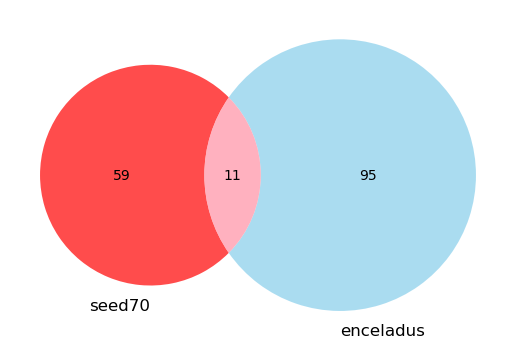

In [14]:
from matplotlib_venn import venn2

# Create a Venn diagram for 2 sets
venn2(subsets=[set(seed70), enceladus_seed], set_labels=('seed70', 'enceladus'),
      set_colors=('red', 'skyblue'), alpha=0.7)

# plt.savefig('venn_ToTAL.svg', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
for c in seed70 & enceladus_seed:
    print(c, cpd2name[c])

C00042 Succinate
C00283 Hydrogen sulfide
C00209 Oxalate
C00014 Ammonia
C00011 CO2
C00282 Hydrogen
C00160 Glycolate
C00383 Malonate
C00001 H2O
C00022 Pyruvate
C00149 (S)-Malate


In [16]:
# drawMols(seed70 - enceladus_seed)

In [17]:
# metals + generic cpds
metals = ['Z00020', 'Z00002', 'C00028', 'Z00030', 'C00205', 'Z00006', 'Z00015', 'C00050', 'Z00053', 'Z00055', 'Z00063', 'C17023', 'C00030', 'Z00069', 'Z00064', 'Z00001', 'Z00054', 'Z00060', 'Z00070', 'Z00029', 'Z00034', 'C22155', 'Z00067', 'Z00062', 'Z00033', 'C00023', 'C01330', 'C00071', 'C00034', 'C19609', 'C14819', 'C01335', 'C00069', 'C00305', 'C14818', 'C00070', 'C00175', 'C00038', 'C00238', 'C00080', 'C00150']
for m in metals:
    print(m, cpd2name[m])
print(len(metals))

Z00020 Generic FeS Cluster
Z00002 4Fe4S
C00028 Acceptor
Z00030 Mn
C00205 hn
Z00006 Cobalt
Z00015 Iron
C00050 Metal
Z00053 Tungsten
Z00055 Calcium
Z00063 Generic FeS
C17023 Sulfur donor
C00030 Reduced acceptor
Z00069 Divalent Metal (M2)
Z00064 Molybdenum
Z00001 2Fe2S
Z00054 Zinc
Z00060 Monovalent Metal (M1)
Z00070 Copper
Z00029 Mg
Z00034 Nickel
C22155 [Fe-S] cluster scaffold protein
Z00067 3Fe4S
Z00062 Vanadium
Z00033 Sodium
C00023 Iron
C01330 Sodium cation
C00071 Aldehyde
C00034 Manganese
C19609 Nickel(2+)
C14819 Fe3+
C01335 ROH
C00069 Alcohol
C00305 Magnesium cation
C14818 Fe2+
C00070 Copper
C00175 Cobalt ion
C00038 Zinc cation
C00238 Potassium cation
C00080 H+
C00150 Molybdenum
41


# run network expansion

In [18]:
# function to draw trajectory

def drawNE(fm):
    iter2cpds = {}
    for c, i in fm.scope.cpd_iteration_dict.items():
        if i not in iter2cpds.keys():
            iter2cpds[i] = [c]
        else:
            iter2cpds[i].append(c)
            
    iter2cpdsNum = {}
    for i in iter2cpds.keys():
        iter2cpdsNum[i] = len(iter2cpds[i])
        
    plt.figure(figsize=(30, 5))
    plt.plot(iter2cpdsNum.values(), color='k')
    
    plt.xlim([0, max(iter2cpdsNum.keys())])
    plt.ylim([0, max(iter2cpdsNum.values())+10])
    plt.xlabel('iteration', fontsize='18')
    plt.ylabel('# cpds discovered', fontsize='18')
    plt.xticks(fontsize='18')
    plt.yticks(fontsize='18')
    
    # plt.savefig('vanilla_iter_vs_cpds_10AA.svg', dpi=300, bbox_inches='tight')
    plt.show()

In [19]:
import networkExpansionPy.folds as nf
import pandas as pd
from collections import Counter
from pathlib import PurePath, Path

# seed = sys.argv[1]
# random.seed(seed)
asset_path = nf.asset_path

# for vanilla
METABOLISM_PATH = PurePath(asset_path, "metabolic_networks","metabolism.v8.01May2023.pkl") # path to metabolism object pickle
RN2RULES_PATH = PurePath(asset_path,"rn2fold","rn2rules.20230224.pkl") # path to rn2rules object pickle
SEED_CPDS_PATH = PurePath(asset_path, "compounds", "seeds.Goldford2022.csv") # path to seed compounds csv

# for FOLD-GATED
ALGORITHM = "no_look_ahead_rules"
WRITE = True # write result to disk
WRITE_TMP = False # write after each iteration
CUSTOM_WRITE_PATH = None # if writing result, custom path to write to
STR_TO_APPEND_TO_FNAME = None # if writing result, str to append to filename
ORDERED_OUTCOME = False # ignore random seed and always choose folds based on sort order
IGNORE_REACTION_VERSIONS = True # when maximizing for reactions, don't count versioned reactions

## Metabolism
metabolism = pd.read_pickle(METABOLISM_PATH)
# remove reactions that produce H2O2 before O2
H2O2_rns = ['R00017_v1', 'R03532_v1', 'R09507_v1', 'R09740_v1', 'R09741_v1', 'R11522', 'R12455', 'R12454']
condition = ((metabolism.network['rn'].isin(H2O2_rns)) & (metabolism.network['direction'] == 'reverse'))
metabolism.network = metabolism.network[~condition]
assert 'R00017_v1' not in list(metabolism.network['rn'])

## FoldRules
rn2rules = pd.read_pickle(RN2RULES_PATH)
foldrules = nf.FoldRules.from_rn2rules(rn2rules)

## Modify seeds with AA and GATP_rns
aa_cids = set(["C00037",
    "C00041",
    "C00065",
    "C00188",
    "C00183",
    "C00407",
    "C00123",
    "C00148",
    "C00049",
    "C00025"])

GATP_rns = {'R00200_gATP_v1',
    'R00200_gATP_v2',
    'R00430_gGTP_v1',
    'R00430_gGTP_v2',
    'R01523_gATP_v1',
    'R04144_gATP_v1',
    'R04208_gATP',
    'R04463_gATP',
    'R04591_gATP_v1',
    'R06836_gATP',
    'R06974_gATP',
    'R06975_gATP_v1'}

# seed = nf.Params(
#     rns = set(metabolism.network["rn"]) - set(rn2rules) | GATP_rns,  # start with non-fold-gated reactions
#     cpds = set((pd.read_csv(SEED_CPDS_PATH)["ID"])),
#     folds = set(['spontaneous'])
# )

## modified seed (seed70, enceladus_seed etc.)
seed = nf.Params(
    rns = set(metabolism.network["rn"]) | GATP_rns,  # start with non-fold-gated reactions + GATP_rns
    cpds = enceladus_seed | set(['C00009']) | set(metals),
    folds = set(['spontaneous'])
)

## Inititalize fold metabolism
fm = nf.FoldMetabolism(metabolism, foldrules, seed)

calculating scope...


/Users/tseamuscorlett/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:556: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  X,Y = netExp_trace(R,P,x0,b)


...done.


In [20]:
full = fm.scope.cpds

In [21]:
len(fm.scope.cpds)

4260

In [22]:
for c in full - fm.scope.cpds:
    print(c, cpd2name[c])

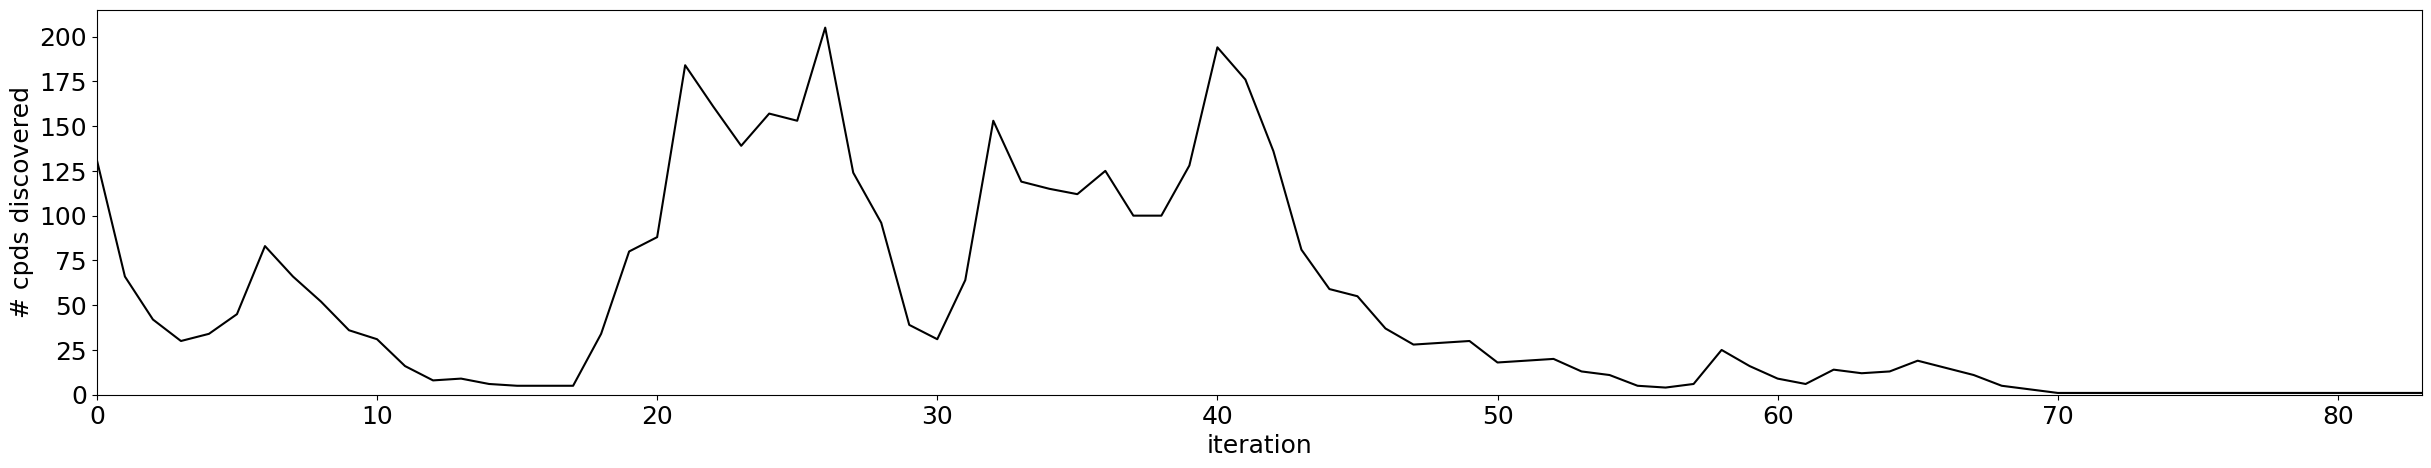

In [23]:
# seed70
drawNE(fm)

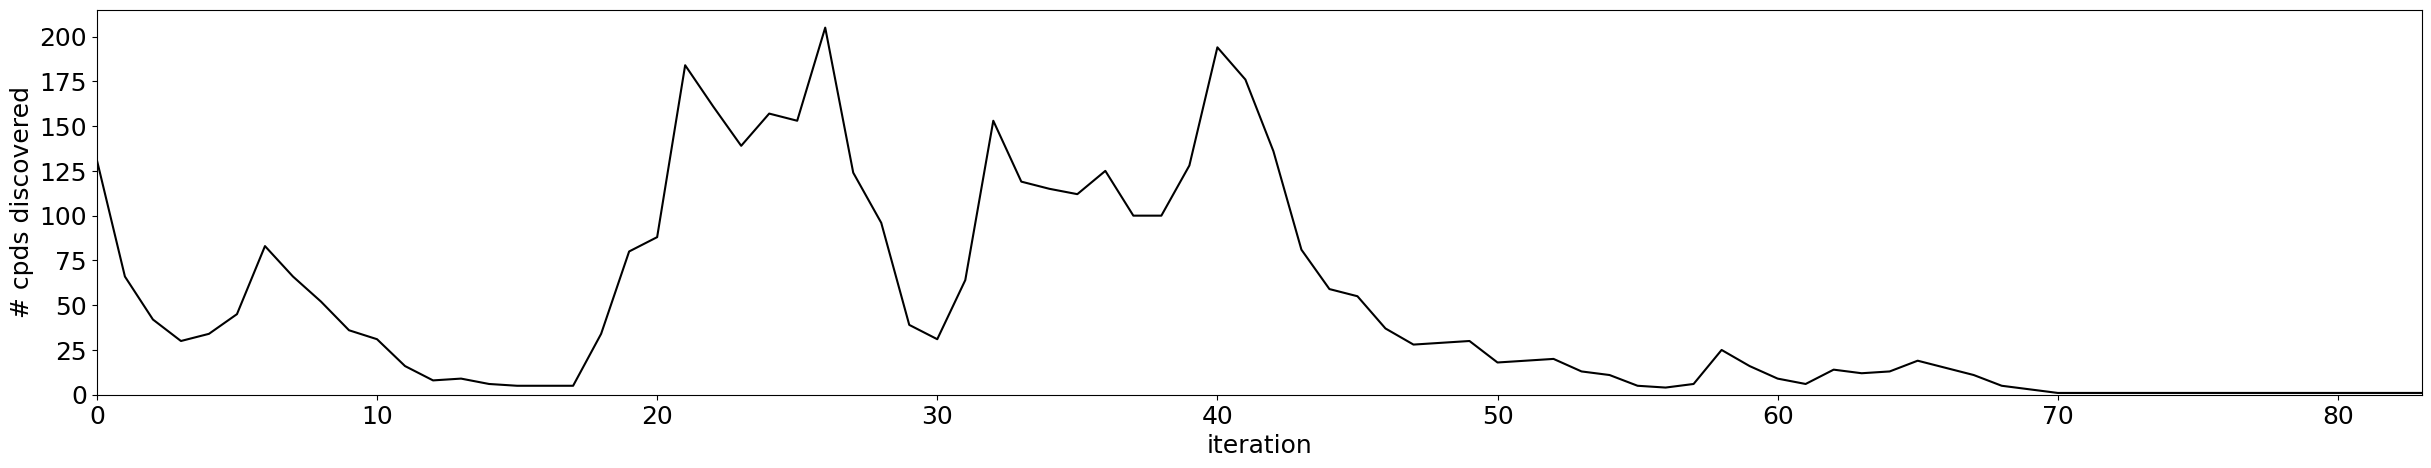

(148, 4260)

In [24]:
# enceladus_seed
drawNE(fm)
len(fm.seed.cpds), len(fm.scope.cpds)

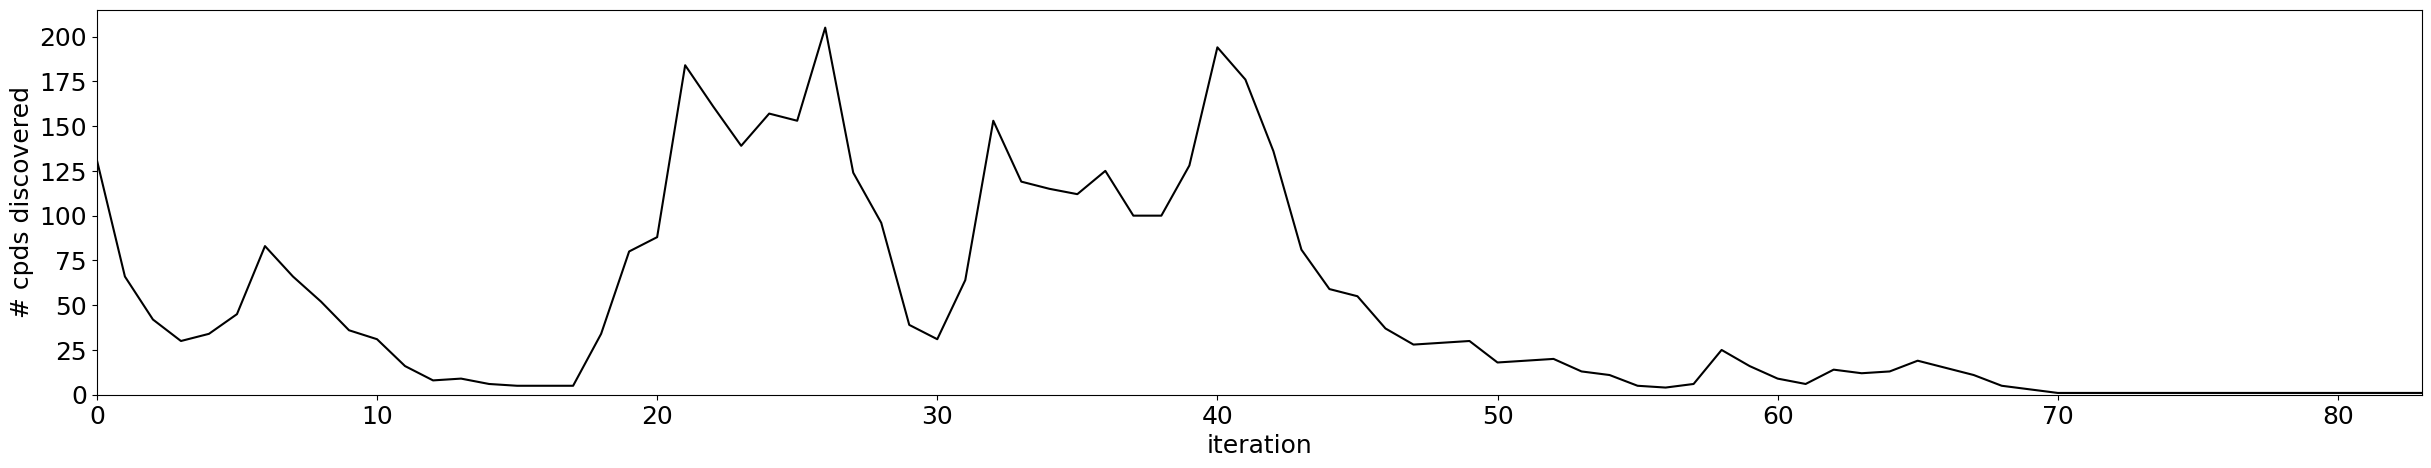

(148, 4260)

In [25]:
# enceladus_seed + metals
drawNE(fm)
len(fm.seed.cpds), len(fm.scope.cpds)

In [26]:
iter2cpds = {}
for c, i in fm.scope.cpd_iteration_dict.items():
    if i not in iter2cpds.keys():
        iter2cpds[i] = [c]
    else:
        iter2cpds[i].append(c)

In [27]:
# print cpds at iter 
for c in iter2cpds[1]:
    print(c, cpd2name[c])

C03738 gamma-L-Glutamyl-D-alanine
C00197 3-Phospho-D-glycerate
C00993 D-Alanyl-D-alanine
C00036 Oxaloacetate
C02218 Dehydroalanine
C00027 Hydrogen peroxide
C01732 Mesaconate
C02532 O-Phospho-D-serine
C03722 Quinolinate
C01444 Oxamate
C00722 Epoxide
C01353 Carbonic acid
Z00039 Pyruvoyl
C00084 Acetaldehyde
C00375 RCH2NH2
C01566 Cyanamide
C00164 Acetoacetate
C00417 cis-Aconitate
C00146 Phenol
C02226 2-Methylmaleate
C00990 5-Aminopentanamide
C01596 Maleamate
C00311 Isocitrate
C19779 beta-Alaninamide
C01066 Cyclohexane-1,3-dione
C01255 N-(6-Aminohexanoyl)-6-aminohexanoate
C05714 alpha-Aminopropiononitrile
C00631 2-Phospho-D-glycerate
C03248 Acetylenedicarboxylate
C03981 2-Hydroxyethylenedicarboxylate
C00813 Barbiturate
C02512 3-Cyano-L-alanine
C00087 Sulfur
C06680 4-Hydroxyphthalate
C02704 Monomethyl sulfate
C01563 Carbamate
C00048 Glyoxylate
C00161 2-Oxo acid
C00013 Diphosphate
C14097 2-Hydroxyisophthalic acid
C05359 e-
C05669 beta-Nitropropanoate
C17205 (R)-2-O-Sulfolactate
C06033 Parapyr

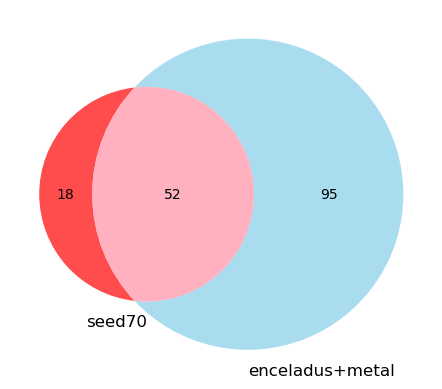

In [28]:
venn2(subsets=[set(seed70), (enceladus_seed | set(metals))], set_labels=('seed70', 'enceladus+metal'),
      set_colors=('red', 'skyblue'), alpha=0.7)

# plt.savefig('venn_ToTAL.svg', dpi=300, bbox_inches='tight')
plt.show()

In [29]:
# which seed is necessary to "rescue"?

rescue = set(seed70) - (enceladus_seed | set(metals))
for c in rescue:
    print(c, cpd2name[c])

C00036 Oxaloacetate
C06232 Molybdate
C01127 4-Hydroxy-2-oxoglutarate
C00122 Fumarate
C00417 cis-Aconitate
C00012 Peptide
C00311 Isocitrate
C01528 Hydrogen selenide
C00009 Orthophosphate
C01732 Mesaconate
C00033 Acetate
C00026 2-Oxoglutarate
C00058 Formate
C20679 Tungstate
C19806 Propane-1,2,3-tricarboxylate
C00288 HCO3-
C00048 Glyoxylate
C00161 2-Oxo acid


In [30]:
# HCO3-?, Molybdate?, Tungstate?, Hydrogen selenide?, Formate? Acetate?

In [31]:
# add 1 seed at a time
plusOne2ns = {}

for plusOne in rescue:
    
    ## FoldRules
    rn2rules = pd.read_pickle(RN2RULES_PATH)
    foldrules = nf.FoldRules.from_rn2rules(rn2rules)
    
    seed = nf.Params(
        rns = set(metabolism.network["rn"]) | GATP_rns,  # start with non-fold-gated reactions + GATP_rns
        cpds = enceladus_seed | set(metals) | set([plusOne]),
        folds = set(['spontaneous'])
    )
    
    fm = nf.FoldMetabolism(metabolism, foldrules, seed)
    print(len(fm.scope.cpds), plusOne, cpd2name[plusOne])
    plusOne2ns[plusOne] = len(fm.scope.cpds)

calculating scope...


/Users/tseamuscorlett/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:556: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  X,Y = netExp_trace(R,P,x0,b)


...done.
255 C00036 Oxaloacetate
calculating scope...


/Users/tseamuscorlett/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:556: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  X,Y = netExp_trace(R,P,x0,b)


...done.
256 C06232 Molybdate
calculating scope...


...

/Users/tseamuscorlett/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:556: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  X,Y = netExp_trace(R,P,x0,b)


...done.
255 C00288 HCO3-
calculating scope...


/Users/tseamuscorlett/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:556: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  X,Y = netExp_trace(R,P,x0,b)


...done.
255 C00048 Glyoxylate
calculating scope...
...done.
255 C00161 2-Oxo acid


/Users/tseamuscorlett/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:556: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  X,Y = netExp_trace(R,P,x0,b)


In [32]:
for key in plusOne2ns.keys():
    print(plusOne2ns[key], key, cpd2name[key])

255 C00036 Oxaloacetate
256 C06232 Molybdate
255 C01127 4-Hydroxy-2-oxoglutarate
255 C00122 Fumarate
255 C00417 cis-Aconitate
259 C00012 Peptide
255 C00311 Isocitrate
259 C01528 Hydrogen selenide
4260 C00009 Orthophosphate
255 C01732 Mesaconate
255 C00033 Acetate
276 C00026 2-Oxoglutarate
255 C00058 Formate
256 C20679 Tungstate
256 C19806 Propane-1,2,3-tricarboxylate
255 C00288 HCO3-
255 C00048 Glyoxylate
255 C00161 2-Oxo acid


In [33]:
# # add 2 seeds at a time
# import itertools

# plusTwo2ns = {}

# for combo in itertools.combinations(rescue, 2):
#     seed = nf.Params(
#         rns = set(metabolism.network["rn"]) | GATP_rns,  # start with non-fold-gated reactions + GATP_rns
#         cpds = enceladus_seed | set(metals) | set(combo),
#         folds = set(['spontaneous'])
#     )
    
#     ## Inititalize fold metabolism
#     fm = nf.FoldMetabolism(metabolism, foldrules, seed)
#     print(len(fm.scope.cpds), combo, cpd2name[combo[0]], cpd2name[combo[1]])
#     plusTwo2ns[combo] = len(fm.scope.cpds)

In [34]:
# for key in plusTwo2ns.keys():
#     print(plusTwo2ns[key], key, cpd2name[key[0]], cpd2name[key[1]])

In [35]:
# enceladus with phosphate, no 'metals'

seed = nf.Params(
        rns = set(metabolism.network["rn"]) | GATP_rns,  # start with non-fold-gated reactions + GATP_rns
        cpds = enceladus_seed | set(['C00009']),
        folds = set(['spontaneous'])
    )
    
## Inititalize fold metabolism
fm = nf.FoldMetabolism(metabolism, foldrules, seed)
print(len(fm.scope.cpds))

calculating scope...
...done.
156


/Users/tseamuscorlett/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:556: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  X,Y = netExp_trace(R,P,x0,b)


In [36]:
# do paper-by-paper
paper2ns = {}

for paper, cpds_df in papers.items():
    s = set((cpds_df['KEGG_ID']))
    s.remove('0')
    
    seed = nf.Params(
            rns = set(metabolism.network["rn"]) | GATP_rns,  # start with non-fold-gated reactions + GATP_rns
            cpds = s,
            folds = set(['spontaneous'])
        )
    
    ## Inititalize fold metabolism
    fm = nf.FoldMetabolism(metabolism, foldrules, seed)
    print(len(s), len(fm.scope.cpds), paper)
    paper2ns[paper] = len(fm.scope.cpds)

calculating scope...


/Users/tseamuscorlett/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:556: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  X,Y = netExp_trace(R,P,x0,b)


...done.
22 29 peter
calculating scope...


/Users/tseamuscorlett/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:556: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  X,Y = netExp_trace(R,P,x0,b)


...done.
33 55 parker
calculating scope...


/Users/tseamuscorlett/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:556: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  X,Y = netExp_trace(R,P,x0,b)


...done.
10 11 yoshimura
calculating scope...


/Users/tseamuscorlett/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:556: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  X,Y = netExp_trace(R,P,x0,b)


...done.
36 53 takano
calculating scope...
...done.
7 5 oba


/Users/tseamuscorlett/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:556: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  X,Y = netExp_trace(R,P,x0,b)


# plots

In [37]:
# 22 29 peter
# 33 55 parker
# 10 11 yoshimura
# 36 53 takano
# 7 5 oba

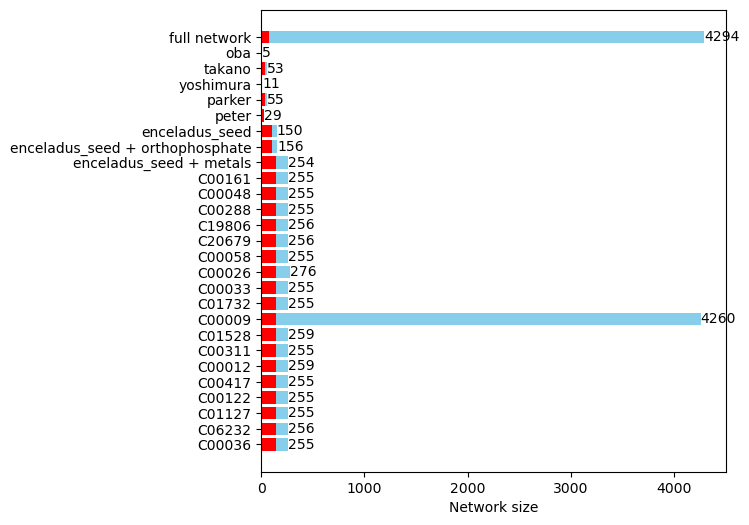

In [38]:
# Create a horizontal bar plot
plt.figure(figsize=(6, 6))

keys, values = list(plusOne2ns.keys()), list(plusOne2ns.values())
keys.append('enceladus_seed + metals')
values.append(254)
keys.append('enceladus_seed + orthophosphate')
values.append(156)
keys.append('enceladus_seed')
values.append(150)
keys.extend(paper2ns.keys())
values.extend(paper2ns.values())
keys.append('full network')
values.append(4294)

plt.barh(keys, values, color='skyblue')
for index, value in enumerate(values):
    plt.text(value + 0.5, index, str(value), va='center', ha='left', color='black')

# red for seed size
values = [145+1]*18
values.extend([145, 106, 107, 22, 33, 10, 36, 7, 70])
plt.barh(keys, values, color='red')


plt.xlabel('Network size')
plt.show()

# Week 3

## Add more cpds to "metals" based on what's available (according to Yasu)
These are also essential for WL pathway!

In [39]:
for c in ['C00009', 'C20679', 'C01528', 'C06232']:
    print(c, cpd2name[c])

metals.extend(['C00009', 'C20679', 'C01528', 'C06232'])
len(metals)

C00009 Orthophosphate
C20679 Tungstate
C01528 Hydrogen selenide
C06232 Molybdate


45

## 1) Is the Enceladus expansion trajectory significantly different from vanilla?
Calculate the Spearman rank corr. coef. of [vanilla+10AA vs. Enceladus] cpd discovery order 

In [40]:
## enceladus
seed = nf.Params(
        rns = set(metabolism.network["rn"]) | GATP_rns,  # start with non-fold-gated reactions + GATP_rns
        cpds = enceladus_seed | set(metals),
        folds = set(['spontaneous'])
    )
    
## Inititalize fold metabolism
fm_e = nf.FoldMetabolism(metabolism, foldrules, seed)
print(len(fm_e.scope.cpds))

## vanilla + 10AA
seed = nf.Params(
    rns = set(metabolism.network["rn"]) | GATP_rns,  # start with non-fold-gated reactions
    cpds = set((pd.read_csv(SEED_CPDS_PATH)["ID"])) | aa_cids,
    folds = set(['spontaneous'])
)
    
## Inititalize fold metabolism
fm = nf.FoldMetabolism(metabolism, foldrules, seed)
print(len(fm.scope.cpds))

calculating scope...


/Users/tseamuscorlett/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:556: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  X,Y = netExp_trace(R,P,x0,b)


...done.
4312
calculating scope...


/Users/tseamuscorlett/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:556: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  X,Y = netExp_trace(R,P,x0,b)


...done.
4294


Spearman rank corr. = 0.8153312633866, p-value = 0.00E+00


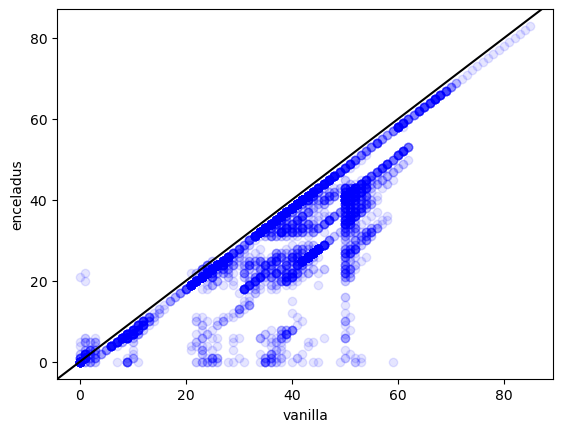

In [42]:
sp, p = spearman(fm.scope.cpd_iteration_dict, fm_e.scope.cpd_iteration_dict)
print(f'Spearman rank corr. = {sp}, p-value = {p}')
scatter(fm.scope.cpd_iteration_dict, fm_e.scope.cpd_iteration_dict, 'vanilla', 'enceladus')

## This has too many data points! Let's look at the level of KEGG pathways (modules).
For each KEGG metabolic module, record the "number of iterations until completion"

In [154]:
# function to check timing of pathway completion 
def pathwayCheck(fm, mods, print=True):
    mod2timing = {}
    iter2rn = {}
    mods_copy = copy.deepcopy(mods)
    
    for rn, i in fm.scope.rn_iteration_dict.items():
        if i not in iter2rn.keys():
            iter2rn[i] = [rn]
        else:
            iter2rn[i].append(rn)
    
    rn_list = []
    for i, rns in iter2rn.items():
        # keep updating rn_list
        rn_list.extend(rns)
        
        # for each mods module, check if all rns in module are in rn_list
        for m in mods_copy:
            if all(item in [item[:6] for item in rn_list] for item in module2rns[m]):
                if print:
                    print(f'{m}: {module2name[m]} is feasible at {i}')
                mod2timing[m] = i
                mods_copy.remove(m)
    return mod2timing

### first, check the carbon metabolism pathways in the previous paper:

In [152]:
cm = ['M00165', 'M00173', 'M00374', 'M00375', 'M00376', 'M00377']

In [50]:
print(len(fm.seed.cpds))  # 80 seed
mod2t = pathwayCheck(fm, cm)

80
M00165: Reductive pentose phosphate cycle (Calvin cycle) is feasible at 36
M00377: Reductive acetyl-CoA pathway (Wood-Ljungdahl pathway) is feasible at 45
M00173: Reductive citrate cycle (Arnon-Buchanan cycle) is feasible at 52
M00374: Dicarboxylate-hydroxybutyrate cycle is feasible at 53
M00375: Hydroxypropionate-hydroxybutylate cycle is feasible at 56
M00376: 3-Hydroxypropionate bi-cycle is feasible at 57


In [51]:
mod2t = pathwayCheck(fm_e, cm)

M00165: Reductive pentose phosphate cycle (Calvin cycle) is feasible at 25
M00173: Reductive citrate cycle (Arnon-Buchanan cycle) is feasible at 41
M00374: Dicarboxylate-hydroxybutyrate cycle is feasible at 42
M00377: Reductive acetyl-CoA pathway (Wood-Ljungdahl pathway) is feasible at 43
M00375: Hydroxypropionate-hydroxybutylate cycle is feasible at 54
M00376: 3-Hydroxypropionate bi-cycle is feasible at 55


### check all pathways 

In [155]:
mod2t = pathwayCheck(fm, list(module2name.keys()), print=False)

In [156]:
mod2t_e = pathwayCheck(fm_e, list(module2name.keys()), print=False)

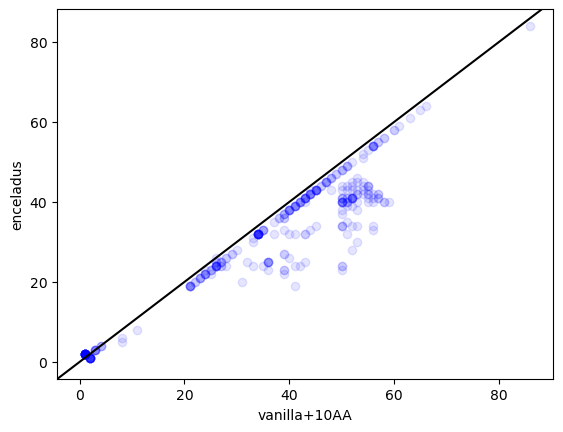

In [157]:
scatter(mod2t, mod2t_e, 'vanilla+10AA', 'enceladus')

In [158]:
# bokeh plot:
d1 = mod2t
d2 = mod2t_e

output_file("scatter.html")
p = figure(width=800, height=800, title="iteration at module completion: vanilla+10AA vs. Enceladus")

# Add annotations
valid_keys, data1, data2 = todata(d1, d2)

source = {'x': data1, 'y': data2, 'label': [key + ' ' + module2name[key] for key in valid_keys]}
p.scatter('x', 'y', source=source, size=10, color='blue', alpha=0.5)

# Add hover tool
hover = HoverTool()
hover.tooltips = [("", "@label"), ("x", "@x"), ("y", "@y")]
p.add_tools(hover)

# Customize plot
p.line([0, max(data1)], [0, max(data1)], line_width=2, color='black', alpha=0.7)
p.xaxis.axis_label = 'vanilla+10AA'
p.yaxis.axis_label = 'enceladus_seed'
p.xaxis.ticker = [0, 20, 40, 60, 80]  # Convert range to list
p.xgrid.grid_line_color = None

# Show the plot
show(p)

## 1b) Can we change the expansion speed even more? (e.g. by adding another compound to the enceladus_seed?)
Add one cpd at a time (from ~4,000 cpds of full network) => check effect on expansion

In [ ]:
# takes 3 hours for ~4,000 cpds

# cpd2effect = {}

# for plusOne in fm.scope.cpds - (set(enceladus_seed) | set(['C00009']) | set(metals)):
#     seed = nf.Params(
#             rns = set(metabolism.network["rn"]) | GATP_rns,  # start with non-fold-gated reactions + GATP_rns
#             cpds = set(enceladus_seed) | set(metals) | set([plusOne]),
#             folds = set(['spontaneous'])
#         )
        
#     fm_p = nf.FoldMetabolism(metabolism, foldrules, seed)
#     sp, p = spearman(fm_p.scope.cpd_iteration_dict, fm_e.scope.cpd_iteration_dict)
#     cpd2effect[plusOne] = sp

In [141]:
# dict2csv(cpd2effect, '../../cpd2effect_enceladus+1.csv')
cpd2effect = csv2dict('../data/assets/cpd2effect_enceladus+1.csv')

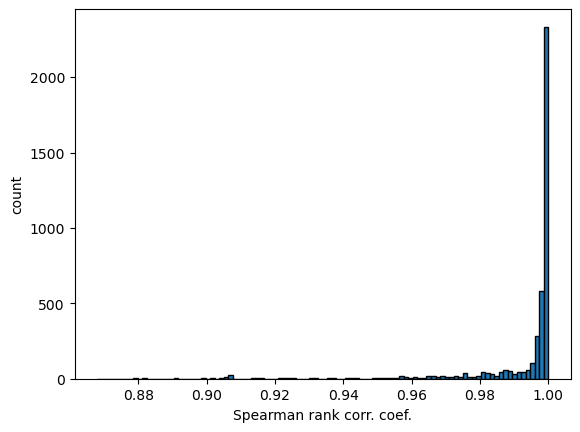

In [163]:
histogram(cpd2effect, bins=100, x_axis='Spearman rank corr. coef.',  y_axis='count')

In [143]:
# print cpds with sp < 0.90

for c, sp in cpd2effect.items():
    if sp < 0.90:
        print(c, sp, cpd2name[c])

C00582 0.8985699987668111 Phenylacetyl-CoA
C00512 0.878682390594941 Benzoyl-CoA
C09809 0.8906859254125803 Cyclohexa-2,5-diene-1-carbonyl-CoA
C16162 0.888696103770576 (9Z,12Z,15Z)-Octadecatrienoyl-CoA
C00412 0.8791596005201124 Stearoyl-CoA
C02041 0.88205204333357 Eicosanoyl-CoA
C02050 0.8927481059648265 Linoleoyl-CoA
C01832 0.8839001285479148 Lauroyl-CoA
C06322 0.8814783043273383 Cyclohexa-1,5-diene-1-carbonyl-CoA
C06749 0.8906914645653614 6-Hydroxycyclohex-1-ene-1-carbonyl-CoA
C00154 0.8680495754812823 Palmitoyl-CoA
C09810 0.8906859254125803 Cyclohexa-1,4-diene-1-carbonyl-CoA
C20413 0.8989686747519507 3,5,7-Trioxododecanoyl-CoA
C02247 0.8787875076709908 Anthraniloyl-CoA
C21452 0.8788573578013597 (2-Aminobenzoyl)acetyl-CoA


In [ ]:
# for sp < 0.9, draw scatterplot => identify major patterns
# they all look similar

# for c, sp in cpd2effect.items():
#     if sp < 0.90:
#         print(c, sp, cpd2name[c])

#         # run network expansion again with plusOne
#         seed = nf.Params(
#         rns = set(metabolism.network["rn"]) | GATP_rns, 
#         cpds = set(enceladus_seed) | set(metals) | set([c]),
#         folds = set(['spontaneous']))
        
#         fm_p = nf.FoldMetabolism(metabolism, foldrules, seed)

#         # get module discovery timing
#         mod2t_p = pathwayCheck(fm_p, list(module2name.keys()))

#         # draw scatterplot
#         scatter(mod2t_e, mod2t_p, 'enceladus', 'enceladus +1')

In [144]:
# bokeh for +C00154

# run network expansion again
c = 'C00154'
seed = nf.Params(
rns = set(metabolism.network["rn"]) | GATP_rns, 
cpds = set(enceladus_seed) | set(metals) | set([c]),
folds = set(['spontaneous']))
fm_p = nf.FoldMetabolism(metabolism, foldrules, seed)

# get module discovery timing
mod2t_p = pathwayCheck(fm_p, list(module2name.keys()), print=False)

# bokeh plot:
d1 = mod2t_e
d2 = mod2t_p

output_file(f"scatter_{c}.html")
p = figure(width=800, height=800, title=f"iteration at module completion: Enceladus vs. Enceladus + {c}: {cpd2name[c]}")

# Add annotations
valid_keys, data1, data2 = todata(d1, d2)

source = {'x': data1, 'y': data2, 'label': [key + ' ' + module2name[key] for key in valid_keys]}
p.scatter('x', 'y', source=source, size=10, color='blue', alpha=0.5)

# Add hover tool
hover = HoverTool()
hover.tooltips = [("", "@label"), ("x", "@x"), ("y", "@y")]
p.add_tools(hover)

# Customize plot
p.line([0, max(data1)], [0, max(data1)], line_width=2, color='black', alpha=0.7)
p.xaxis.axis_label = 'enceladus_seed'
p.yaxis.axis_label = f'enceladus_seed +{c}'
p.xaxis.ticker = [0, 20, 40, 60, 80]  # Convert range to list
p.xgrid.grid_line_color = None

# Show the plot
show(p)

calculating scope...


/Users/tseamuscorlett/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:556: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  X,Y = netExp_trace(R,P,x0,b)


...done.
M00363: EHEC pathogenicity signature, Shiga toxin is feasible at 2
M00415: Fatty acid elongation in endoplasmic reticulum is feasible at 2
M00542: EHEC/EPEC pathogenicity signature, T3SS and effectors is feasible at 2
M00564: Helicobacter pylori pathogenicity signature, cagA pathogenicity island is feasible at 2
M00574: Pertussis pathogenicity signature, pertussis toxin is feasible at 2
M00576: ETEC pathogenicity signature, heat-labile and heat-stable enterotoxins is feasible at 2
M00597: Anoxygenic photosystem II is feasible at 2
M00611: Oxygenic photosynthesis in plants and cyanobacteria is feasible at 2
M00613: Anoxygenic photosynthesis in green nonsulfur bacteria is feasible at 2
M00615: Nitrate assimilation is feasible at 2
M00617: Methanogen is feasible at 2
M00625: Methicillin resistance is feasible at 2
M00639: Multidrug resistance, efflux pump MexCD-OprJ is feasible at 2
M00642: Multidrug resistance, efflux pump MexJK-OprM is feasible at 2
M00649: Multidrug resistance

In [145]:
# relax threshold to .95

for c, sp in cpd2effect.items():
    if sp < 0.95:
        print(c, sp, cpd2name[c])

C20238 0.9061340790098172 (2R)-Ethylmalonyl-CoA
C06027 0.9074975441901053 L-erythro-3-Methylmalyl-CoA
C12092 0.9211809824986551 N-Methylanthraniloyl-CoA
C05117 0.9301313293685642 3-Aminobutanoyl-CoA
C00083 0.9061312785083321 Malonyl-CoA
C00683 0.9065642780020655 (S)-Methylmalonyl-CoA
C20968 0.9229875730058543 3-Hydroxy-3-(methylthio)propanoyl-CoA
C05338 0.9037127861006489 4-Hydroxyphenylacetyl-CoA
C03724 0.9067777327072769 S-(5-Hydroxy-2-furoyl)-CoA
C16327 0.9419742643271821 OPC8-CoA
C06028 0.9066092403865 2-Methylfumaryl-CoA
C22058 0.9409484595208706 Dihydroisopentenyldehydrorhodopin
C18054 0.9235326186610745 2-Amino-2-deoxyisochorismate
C00100 0.9064597783695042 Propanoyl-CoA
C02949 0.9067445532012144 4-Hydroxybenzoyl-CoA
C07118 0.9211623403010801 Benzoylacetyl-CoA
C00406 0.9145311902015737 Feruloyl-CoA
C07303 0.9145467398775149 4-Hydroxy-3-methoxyphenyl-beta-hydroxypropanoyl-CoA
C00136 0.9011247326951808 Butanoyl-CoA
C05195 0.9444378070100317 3-Hydroxybenzoyl-CoA
C00582 0.8985699987

In [146]:
check = ['C00016', 'C15672', 'C22349', 'C00101', 'C00251']
for c in check:
    print(c, cpd2name[c])

C00016 FAD
C15672 Heme O
C22349 Bacterioruberin
C00101 Tetrahydrofolate
C00251 Chorismate


In [147]:
# boke for 6 compounds
for c in check:
    # run network expansion again
    seed = nf.Params(
    rns = set(metabolism.network["rn"]) | GATP_rns, 
    cpds = set(enceladus_seed) | set(metals) | set([c]),
    folds = set(['spontaneous']))
    fm_p = nf.FoldMetabolism(metabolism, foldrules, seed)
    
    # get module discovery timing
    mod2t_p = pathwayCheck(fm_p, list(module2name.keys()))
    
    # bokeh plot:
    d1 = mod2t_e
    d2 = mod2t_p
    
    output_file(f"scatter_{c}.html")
    p = figure(width=800, height=800, title=f"iteration at module completion: Enceladus vs. Enceladus + {c}: {cpd2name[c]}")
    
    # Add annotations
    valid_keys, data1, data2 = todata(d1, d2)
    
    source = {'x': data1, 'y': data2, 'label': [key + ' ' + module2name[key] for key in valid_keys]}
    p.scatter('x', 'y', source=source, size=10, color='blue', alpha=0.5)
    
    # Add hover tool
    hover = HoverTool()
    hover.tooltips = [("", "@label"), ("x", "@x"), ("y", "@y")]
    p.add_tools(hover)
    
    # Customize plot
    p.line([0, max(data1)], [0, max(data1)], line_width=2, color='black', alpha=0.7)
    p.xaxis.axis_label = 'enceladus_seed'
    p.yaxis.axis_label = f'enceladus_seed +{c}'
    p.xaxis.ticker = [0, 20, 40, 60, 80]  # Convert range to list
    p.xgrid.grid_line_color = None
    
    # Show the plot
    show(p)

calculating scope...


/Users/tseamuscorlett/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:556: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  X,Y = netExp_trace(R,P,x0,b)


...done.
M00363: EHEC pathogenicity signature, Shiga toxin is feasible at 2
M00415: Fatty acid elongation in endoplasmic reticulum is feasible at 2
M00542: EHEC/EPEC pathogenicity signature, T3SS and effectors is feasible at 2
M00564: Helicobacter pylori pathogenicity signature, cagA pathogenicity island is feasible at 2
M00574: Pertussis pathogenicity signature, pertussis toxin is feasible at 2
M00576: ETEC pathogenicity signature, heat-labile and heat-stable enterotoxins is feasible at 2
M00597: Anoxygenic photosystem II is feasible at 2
M00611: Oxygenic photosynthesis in plants and cyanobacteria is feasible at 2
M00613: Anoxygenic photosynthesis in green nonsulfur bacteria is feasible at 2
M00615: Nitrate assimilation is feasible at 2
M00617: Methanogen is feasible at 2
M00625: Methicillin resistance is feasible at 2
M00639: Multidrug resistance, efflux pump MexCD-OprJ is feasible at 2
M00642: Multidrug resistance, efflux pump MexJK-OprM is feasible at 2
M00649: Multidrug resistance

/Users/tseamuscorlett/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:556: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  X,Y = netExp_trace(R,P,x0,b)


...done.
M00363: EHEC pathogenicity signature, Shiga toxin is feasible at 2
M00415: Fatty acid elongation in endoplasmic reticulum is feasible at 2
M00542: EHEC/EPEC pathogenicity signature, T3SS and effectors is feasible at 2
M00564: Helicobacter pylori pathogenicity signature, cagA pathogenicity island is feasible at 2
M00574: Pertussis pathogenicity signature, pertussis toxin is feasible at 2
M00576: ETEC pathogenicity signature, heat-labile and heat-stable enterotoxins is feasible at 2
M00597: Anoxygenic photosystem II is feasible at 2
M00611: Oxygenic photosynthesis in plants and cyanobacteria is feasible at 2
M00613: Anoxygenic photosynthesis in green nonsulfur bacteria is feasible at 2
M00615: Nitrate assimilation is feasible at 2
M00617: Methanogen is feasible at 2
M00625: Methicillin resistance is feasible at 2
M00639: Multidrug resistance, efflux pump MexCD-OprJ is feasible at 2
M00642: Multidrug resistance, efflux pump MexJK-OprM is feasible at 2
M00649: Multidrug resistance

...

...done.
M00363: EHEC pathogenicity signature, Shiga toxin is feasible at 2
M00415: Fatty acid elongation in endoplasmic reticulum is feasible at 2
M00542: EHEC/EPEC pathogenicity signature, T3SS and effectors is feasible at 2
M00564: Helicobacter pylori pathogenicity signature, cagA pathogenicity island is feasible at 2
M00574: Pertussis pathogenicity signature, pertussis toxin is feasible at 2
M00576: ETEC pathogenicity signature, heat-labile and heat-stable enterotoxins is feasible at 2
M00597: Anoxygenic photosystem II is feasible at 2
M00611: Oxygenic photosynthesis in plants and cyanobacteria is feasible at 2
M00613: Anoxygenic photosynthesis in green nonsulfur bacteria is feasible at 2
M00615: Nitrate assimilation is feasible at 2
M00617: Methanogen is feasible at 2
M00625: Methicillin resistance is feasible at 2
M00639: Multidrug resistance, efflux pump MexCD-OprJ is feasible at 2
M00642: Multidrug resistance, efflux pump MexJK-OprM is feasible at 2
M00649: Multidrug resistance

/Users/tseamuscorlett/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:556: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  X,Y = netExp_trace(R,P,x0,b)


...done.
M00363: EHEC pathogenicity signature, Shiga toxin is feasible at 2
M00415: Fatty acid elongation in endoplasmic reticulum is feasible at 2
M00542: EHEC/EPEC pathogenicity signature, T3SS and effectors is feasible at 2
M00564: Helicobacter pylori pathogenicity signature, cagA pathogenicity island is feasible at 2
M00574: Pertussis pathogenicity signature, pertussis toxin is feasible at 2
M00576: ETEC pathogenicity signature, heat-labile and heat-stable enterotoxins is feasible at 2
M00597: Anoxygenic photosystem II is feasible at 2
M00611: Oxygenic photosynthesis in plants and cyanobacteria is feasible at 2
M00613: Anoxygenic photosynthesis in green nonsulfur bacteria is feasible at 2
M00615: Nitrate assimilation is feasible at 2
M00617: Methanogen is feasible at 2
M00625: Methicillin resistance is feasible at 2
M00639: Multidrug resistance, efflux pump MexCD-OprJ is feasible at 2
M00642: Multidrug resistance, efflux pump MexJK-OprM is feasible at 2
M00649: Multidrug resistance

/Users/tseamuscorlett/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:556: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  X,Y = netExp_trace(R,P,x0,b)


...done.
M00363: EHEC pathogenicity signature, Shiga toxin is feasible at 2
M00415: Fatty acid elongation in endoplasmic reticulum is feasible at 2
M00542: EHEC/EPEC pathogenicity signature, T3SS and effectors is feasible at 2
M00564: Helicobacter pylori pathogenicity signature, cagA pathogenicity island is feasible at 2
M00574: Pertussis pathogenicity signature, pertussis toxin is feasible at 2
M00576: ETEC pathogenicity signature, heat-labile and heat-stable enterotoxins is feasible at 2
M00597: Anoxygenic photosystem II is feasible at 2
M00611: Oxygenic photosynthesis in plants and cyanobacteria is feasible at 2
M00613: Anoxygenic photosynthesis in green nonsulfur bacteria is feasible at 2
M00615: Nitrate assimilation is feasible at 2
M00617: Methanogen is feasible at 2
M00625: Methicillin resistance is feasible at 2
M00639: Multidrug resistance, efflux pump MexCD-OprJ is feasible at 2
M00642: Multidrug resistance, efflux pump MexJK-OprM is feasible at 2
M00649: Multidrug resistance

## 2) Leave-One-Out analysis
If we remove one seed cpd at a time from enceladus_seed, which cpd will have the largest reduction in network size?

In [60]:
len(enceladus_seed | set(metals))

151

In [ ]:
# cpd2loo = {}

# for c in enceladus_seed | set(metals):
#     seed = nf.Params(
#             rns = set(metabolism.network["rn"]) | GATP_rns,  # start with non-fold-gated reactions + GATP_rns
#             cpds = (enceladus_seed | set(metals)) - set([c]),
#             folds = set(['spontaneous'])
#         )
        
#     fm_loo = nf.FoldMetabolism(metabolism, foldrules, seed)
#     cpd2loo[c] = len(fm_loo.scope.cpds)

In [149]:
# dict2csv(cpd2loo, '../../cpd2loo.csv')
cpd2loo = csv2dict('../data/assets/cpd2loo.csv')

In [65]:
cpd2loo

{'C07446': 4311,
 'C01950': 4312,
 'C01799': 4312,
 'C06417': 4312,
 'Z00053': 4312,
 'C15521': 4311,
 'C05578': 4312,
 'C06232': 4293,
 'Z00001': 4312,
 'Z00069': 4312,
 'Z00015': 4312,
 'C01432': 4312,
 'C06104': 4312,
 'C00022': 4312,
 'C00149': 4312,
 'Z00034': 4312,
 'C01020': 4312,
 'C00711': 4312,
 'C00132': 4312,
 'C00049': 4312,
 'Z00062': 4311,
 'C01845': 4312,
 'C00320': 4312,
 'C00001': 4312,
 'C14818': 4312,
 'C02421': 4312,
 'C00106': 4312,
 'C05979': 4312,
 'Z00063': 4312,
 'C14819': 4312,
 'C02356': 4312,
 'C00418': 4312,
 'C00011': 4312,
 'C00587': 4312,
 'C01089': 4312,
 'C02378': 4312,
 'C00153': 4312,
 'C00123': 4312,
 'C10164': 4312,
 'C00030': 4312,
 'C00305': 4281,
 'C02614': 4312,
 'C15588': 4311,
 'C20679': 4310,
 'C00186': 4312,
 'C01335': 4307,
 'C00407': 4312,
 'C00258': 4312,
 'C05529': 4312,
 'Z00064': 4312,
 'C00037': 4312,
 'C05123': 4312,
 'C00237': 4312,
 'C00160': 4312,
 'C00218': 4312,
 'C00431': 4312,
 'C06418': 4312,
 'C00086': 4312,
 'C02261': 431

In [166]:
for c, i in cpd2loo.items():
    print(i, c, cpd2name[c])

4311 C07446 Isonicotinic acid
4312 C01950 Picolinamide
4312 C01799 D-Norvaline
4312 C06417 D-Valine
4312 Z00053 Tungsten
4311 C15521 Alkanesulfonate
4312 C05578 5,6-Dihydroxyindole
4293 C06232 Molybdate
4312 Z00001 2Fe2S
4312 Z00069 Divalent Metal (M2)
4312 Z00015 Iron
4312 C01432 Lactate
4312 C06104 Adipate
4312 C00022 Pyruvate
4312 C00149 (S)-Malate
4312 Z00034 Nickel
4312 C01020 6-Hydroxynicotinate
4312 C00711 Malate
4312 C00132 Methanol
4312 C00049 L-Aspartate
4311 Z00062 Vanadium
4312 C01845 Propan-2-ol
4312 C00320 Thiosulfate
4312 C00001 H2O
4312 C14818 Fe2+
4312 C02421 Isonicotineamide
4312 C00106 Uracil
4312 C05979 Propane-1-ol
4312 Z00063 Generic FeS
4312 C14819 Fe3+
4312 C02356 (S)-2-Aminobutanoate
4312 C00418 (R)-Mevalonate
4312 C00011 CO2
4312 C00587 3-Hydroxybenzoate
4312 C01089 (R)-3-Hydroxybutanoate
4312 C02378 6-Aminohexanoate
4312 C00153 Nicotinamide
4312 C00123 L-Leucine
4312 C10164 Picolinic acid
4312 C00030 Reduced acceptor
4281 C00305 Magnesium cation
4312 C02614 (

### What about LOO with vanilla expansion?

In [165]:
# cpd2loo_vanilla = {}

# for c in set((pd.read_csv(SEED_CPDS_PATH)["ID"])):
#     seed = nf.Params(
#             rns = set(metabolism.network["rn"]) | GATP_rns,  # start with non-fold-gated reactions + GATP_rns
#             cpds = set((pd.read_csv(SEED_CPDS_PATH)["ID"])) - set([c]),
#             folds = set(['spontaneous'])
#         )
        
#     fm_loo = nf.FoldMetabolism(metabolism, foldrules, seed)
#     cpd2loo_vanilla[c] = len(fm_loo.scope.cpds)

In [150]:
# dict2csv(cpd2loo_vanilla, '../../cpd2loo_vanilla.csv')
cpd2loo_vanilla = csv2dict('../data/assets/cpd2loo_vanilla.csv')

In [71]:
for c, i in cpd2loo_vanilla.items():
    print(i, c, cpd2name[c])

4294 C00042 Succinate
431 Z00030 Mn
4271 C06232 Molybdate
4232 C00175 Cobalt ion
4294 Z00029 Mg
4294 C00071 Aldehyde
4294 C00122 Fumarate
4294 Z00053 Tungsten
4264 C00238 Potassium cation
4294 C00282 Hydrogen
4294 Z00001 2Fe2S
4294 Z00069 Divalent Metal (M2)
4265 C01528 Hydrogen selenide
4294 C01732 Mesaconate
4294 Z00006 Cobalt
394 C00026 2-Oxoglutarate
4293 C19806 Propane-1,2,3-tricarboxylate
4294 C00022 Pyruvate
4294 C22155 [Fe-S] cluster scaffold protein
4293 C00150 Molybdenum
4294 C00149 (S)-Malate
4294 Z00054 Zinc
4294 C00036 Oxaloacetate
1455 C00283 Hydrogen sulfide
4294 Z00067 3Fe4S
4294 Z00034 Nickel
135 C00009 Orthophosphate
4294 C00417 cis-Aconitate
4294 C00080 H+
4293 Z00062 Vanadium
4294 C00001 H2O
4294 C00033 Acetate
4294 C00058 Formate
4293 C00038 Zinc cation
4294 Z00063 Generic FeS
4294 C14819 Fe3+
4294 C00048 Glyoxylate
4294 C00050 Metal
4294 C00161 2-Oxo acid
4134 C00023 Iron
4294 C01127 4-Hydroxy-2-oxoglutarate
247 C00014 Ammonia
4294 Z00033 Sodium
4294 C00011 CO2
42

## leave one-group out
enceladus_seed set is robust to perturbation... let's remove groups of cpds

In [95]:
for paper in papers:
    s = set(papers[paper]['KEGG_ID'])
    s.remove('0')
    print(paper, s)

peter {'C01326', 'C00189', 'C00282', 'C01380', 'C01548', 'C00007', 'C00283', 'C00132', 'C01845', 'C00001', 'C20783', 'C05979', 'C00014', 'C00479', 'C00011', 'C19316', 'C15588', 'C01438', 'C00237', 'C00218', 'C11505', 'C00207'}
parker {'C00133', 'C01799', 'C06417', 'C06748', 'C00716', 'C00334', 'C00049', 'C00065', 'C00183', 'C02356', 'C00099', 'C00402', 'C01570', 'C02378', 'C00064', 'C00123', 'C00041', 'C00819', 'C00407', 'C01826', 'C03665', 'C00820', 'C00037', 'C03284', 'C00188', 'C00218', 'C00740', 'C02261', 'C06418', 'C00431', 'C01401', 'C01205', 'C00797'}
yoshimura {'C00283', 'C01861', 'C02084', 'C15521', 'C05123', 'C00094', 'C00320', 'C11145', 'C00059', 'C05529'}
takano {'C00042', 'C05578', 'C00256', 'C01432', 'C16363', 'C06104', 'C00022', 'C00149', 'C00158', 'C00497', 'C00805', 'C00711', 'C01020', 'C02104', 'C00156', 'C00581', 'C20827', 'C00418', 'C00587', 'C01089', 'C01454', 'C02129', 'C05984', 'C02614', 'C00186', 'C00258', 'C00209', 'C01384', 'C00160', 'C00489', 'C00086', 'C0081

In [84]:
cpd2loo_paper = {}

for paper in papers:
    s = set(papers[paper]['KEGG_ID'])
    s.remove('0')
    
    seed = nf.Params(
            rns = set(metabolism.network["rn"]) | GATP_rns,  # start with non-fold-gated reactions + GATP_rns
            cpds = (enceladus_seed | set(metals)) - s,
            folds = set(['spontaneous'])
        )
        
    print(len((enceladus_seed | set(metals)) - s))
    fm_loo = nf.FoldMetabolism(metabolism, foldrules, seed)
    cpd2loo_paper[paper] = len(fm_loo.scope.cpds)

129
calculating scope...


/Users/tseamuscorlett/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:556: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  X,Y = netExp_trace(R,P,x0,b)


...done.
118
calculating scope...


/Users/tseamuscorlett/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:556: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  X,Y = netExp_trace(R,P,x0,b)


...done.
141
calculating scope...


...

...done.
115
calculating scope...


/Users/tseamuscorlett/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:556: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  X,Y = netExp_trace(R,P,x0,b)


...done.
144
calculating scope...


/Users/tseamuscorlett/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:556: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  X,Y = netExp_trace(R,P,x0,b)


...done.


In [85]:
cpd2loo_paper
# removing parker or yoshimura restricts expansion

{'peter': 4308, 'parker': 572, 'yoshimura': 2233, 'takano': 4304, 'oba': 4311}

## which amino acid is important? Let's leave out one AA at a time

In [93]:
papers['parker'][['compound_names','KEGG_ID']]

,compound_names,KEGG_ID
80,glycine,C00037
81,D-Ala,C00133
82,L-Ala,C00041
83,Ala,C01401
84,D-Ser,C00740
85,L-Ser,C00065
86,Serine,C00716
87,beta-Ala,C00099
88,D-Asp,C00402
89,L-Asp,C00049


In [108]:
AAs = {}
AAs['Glycine'] = ['C00037']
AAs['Alanine'] = ['C00133', 'C00099', 'C00041', 'C01401']
AAs['Serine'] = ['C00716', 'C00065', 'C00740']
AAs['Aspartate'] = ['C00049', 'C00402']
AAs['Threonine'] = ['C00820', 'C00188']
AAs['ABA'] = ['C02261', 'C02356', 'C00334']
AAs['AIB'] = ['C03665', 'C01205', 'C03284']
AAs['Glutanime'] = ['C00064', 'C00819']
AAs['Leucine'] = ['C01570', 'C00123']
AAs['Isoleucine'] = ['C06418', 'C00407']
AAs['Valine'] = ['C06417', 'C00183']
AAs['Norvaline'] = ['C01826', 'C01799']
AAs['others'] = ['C02378', 'C00431', 'C00218', 'C00797', 'C06748']

In [110]:
# # leave amino_acid out

# cpd2loo_AA = {}

# for AA in AAs:
#     s = set(AAs[AA])
    
#     seed = nf.Params(
#             rns = set(metabolism.network["rn"]) | GATP_rns,  # start with non-fold-gated reactions + GATP_rns
#             cpds = (enceladus_seed | set(metals)) - s,
#             folds = set(['spontaneous'])
#         )
        
#     print(len((enceladus_seed | set(metals)) - s))
#     fm_loo = nf.FoldMetabolism(metabolism, foldrules, seed)
#     cpd2loo_AA[AA] = len(fm_loo.scope.cpds)

150
calculating scope...


/Users/tseamuscorlett/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:556: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  X,Y = netExp_trace(R,P,x0,b)


...done.
147
calculating scope...


/Users/tseamuscorlett/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:556: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  X,Y = netExp_trace(R,P,x0,b)


...done.
148
calculating scope...


...

...done.
149
calculating scope...


/Users/tseamuscorlett/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:556: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  X,Y = netExp_trace(R,P,x0,b)


...done.
146
calculating scope...


/Users/tseamuscorlett/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:556: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  X,Y = netExp_trace(R,P,x0,b)


...done.


In [111]:
cpd2loo_AA

{'Glycine': 4312,
 'Alanine': 4312,
 'Serine': 4311,
 'Aspartate': 4312,
 'Threonine': 4312,
 'ABA': 4312,
 'AIB': 4312,
 'Glutanime': 4312,
 'Leucine': 4312,
 'Isoleucine': 4312,
 'Valine': 4312,
 'Norvaline': 4310,
 'others': 4305}

## amino acids are interconvertible...
Let's remove all 'parker' amino acids => add back one AA at a time

In [119]:
len((enceladus_seed | set(metals)))

151

In [136]:
len((enceladus_seed | set(metals)) - parker)

118

In [137]:
plusOne2ns_AA = {}

for AA in parker:
    
    seed = nf.Params(
            rns = set(metabolism.network["rn"]) | GATP_rns,  # start with non-fold-gated reactions + GATP_rns
            cpds = ((enceladus_seed | set(metals)) - parker) | set([AA]),
            folds = set(['spontaneous'])
        )
        
    fm_loo = nf.FoldMetabolism(metabolism, foldrules, seed)
    print(len(fm_loo.seed.cpds))
    plusOne2ns_AA[AA] = len(fm_loo.scope.cpds)

calculating scope...


/Users/tseamuscorlett/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:556: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  X,Y = netExp_trace(R,P,x0,b)


...done.
119
calculating scope...


/Users/tseamuscorlett/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:556: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  X,Y = netExp_trace(R,P,x0,b)


...done.
119
calculating scope...


...

/Users/tseamuscorlett/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:556: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  X,Y = netExp_trace(R,P,x0,b)


...done.
119
calculating scope...


/Users/tseamuscorlett/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:556: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  X,Y = netExp_trace(R,P,x0,b)


...done.
119
calculating scope...
...done.
119


/Users/tseamuscorlett/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:556: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  X,Y = netExp_trace(R,P,x0,b)


In [140]:
for c, ns in plusOne2ns_AA.items():
    print(ns, c, cpd2name[c])

572 C00133 D-Alanine
572 C01799 D-Norvaline
572 C06417 D-Valine
573 C06748 Isopropylamine
573 C00716 Serine
4302 C00334 4-Aminobutanoate
572 C00049 L-Aspartate
572 C00065 L-Serine
576 C00183 L-Valine
572 C02356 (S)-2-Aminobutanoate
572 C00099 beta-Alanine
572 C00402 D-Aspartate
572 C01570 D-Leucine
576 C02378 6-Aminohexanoate
4302 C00064 L-Glutamine
573 C00123 L-Leucine
572 C00041 L-Alanine
4302 C00819 D-Glutamine
574 C00407 L-Isoleucine
573 C01826 L-Norvaline
572 C03665 2-Amino-2-methylpropanoate
572 C00820 D-Threonine
572 C00037 Glycine
577 C03284 L-3-Aminoisobutanoate
572 C00188 L-Threonine
572 C00218 Methylamine
572 C00740 D-Serine
572 C02261 D-2-Aminobutyrate
572 C06418 D-Isoleucine
575 C00431 5-Aminopentanoate
573 C01401 Alanine
574 C01205 (R)-3-Amino-2-methylpropanoate
573 C00797 Ethylamine


# takeaways? future plans?
1. rewiring cofactors? (ATP -> GTP -> pyrimidine); add 'artificial' reactions that use alternative cofactors; no base? multiple bases?
- i. synthesize the cofactor
- ii. update network to use cofactor (as Z-cofactor vs. real reactant)
2. seed set diversity
-  